<a href="https://colab.research.google.com/github/BuddhikaRoshan/HemoAi/blob/Heshani/IT22570758_MOBILNETcnn%26resnet%2Bvit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import matplotlib.pyplot as plt


import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
# ==========================================
# SETTINGS
# ==========================================
IMG_SIZE = 64
BATCH_SIZE = 8
EPOCHS = 30
SELECTED_SHAPES = 5

TARGET_SHAPE_COUNT = 1000
TARGET_THAL_COUNT = 1000

shape_dir = "/content/drive/MyDrive/thalassemia_shape_based/dataset2/shapes"
disease_dir = "/content/drive/MyDrive/thalassemia_shape_based/dataset/disease"

In [ ]:
def preprocess_image(path):
    img = cv2.imread(path)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Contrast enhancement
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.equalizeHist(l)
    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

In [ ]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

def augment_image_array(img):
    img = tf.expand_dims(img, 0)
    img = augment(img)
    return img[0].numpy()

In [ ]:
def load_shape_data_balanced(folder):
    images, labels = [], []
    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        path = os.path.join(folder, cls)
        if not os.path.isdir(path):
            continue

        files = [f for f in os.listdir(path)
                 if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif'))]

        class_imgs = []

        for file in files:
            img = preprocess_image(os.path.join(path, file))
            if img is not None:
                class_imgs.append(img)

        if len(class_imgs) == 0:
            continue

        # original images
        for img in class_imgs:
            images.append(img)
            labels.append(idx)

        # augmentation to balance
        current = len(class_imgs)
        i = 0
        while current < TARGET_SHAPE_COUNT:
            img = class_imgs[i % len(class_imgs)]
            images.append(augment_image_array(img))
            labels.append(idx)
            current += 1
            i += 1

        print(f"{cls}: {current}")

    return np.array(images), np.array(labels), classes

In [ ]:

from tensorflow.keras import layers, models
import tensorflow as tf

def build_mobilenet_vit_model(num_classes):

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = augment(inputs)

    # -------------------------
    # CNN Backbone (MobileNet)
    # -------------------------
    base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )

    # Freeze most layers
    for layer in base.layers[:-30]:
        layer.trainable = False

    x = base.output   # shape: (None, H, W, C)

    # -------------------------
    # Convert CNN feature map → patches (for ViT)
    # -------------------------
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    num_patches = h * w

    x = layers.Reshape((num_patches, c))(x)

    # Linear projection
    projection_dim = 64
    x = layers.Dense(projection_dim)(x)

    # -------------------------
    # Transformer Block (ViT)
    # -------------------------
    num_heads = 4
    transformer_units = 128

    # LayerNorm
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)

    # Multi-head attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim
    )(x1, x1)

    # Skip connection
    x2 = layers.Add()([attention_output, x])

    # Feed-forward network
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = layers.Dense(transformer_units, activation="relu")(x3)
    x3 = layers.Dense(projection_dim)(x3)

    x = layers.Add()([x3, x2])

    # -------------------------
    # Classification Head
    # -------------------------
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_shape_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
# Ensure shape_classes is defined by loading the data first.
# We only need the classes for building the model in this step.
# X_shapes and y_shapes will be reloaded and properly split in a subsequent cell (s2kObOsT7oN5) for training.
X_dummy, y_dummy, shape_classes = load_shape_data_balanced(shape_dir)
shape_model = build_mobilenet_vit_model(len(shape_classes))

acantocyte: 1000
elliptocyte: 1000
hypochromic: 1000
normal: 1000
pencil: 1000
sperobulat: 1000
stomatocyte: 1000
target: 1000
teardrop: 1000


/tmp/ipykernel_517/3592425324.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Assuming IMG_SIZE is now 96, and shape_dir is defined.
# Need to reload data because IMG_SIZE was changed from 128 to 96.
print("Reloading shape dataset with updated IMG_SIZE...")
X_shapes, y_shapes, shape_classes = load_shape_data_balanced(shape_dir)

# Convert labels to categorical
y_shapes_cat = tf.keras.utils.to_categorical(y_shapes, len(shape_classes))

# Redefine the augment layer with the updated IMG_SIZE
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Rebuild the shape model to ensure its input layer matches the new IMG_SIZE
# and number of classes. `build_mobilenet_vit_model` uses the global IMG_SIZE.
shape_model = build_mobilenet_vit_model(len(shape_classes))

# Split data again with the new X_shapes and y_shapes_cat
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_shapes,
    y_shapes_cat,
    test_size=0.2,
    stratify=y_shapes,   # VERY IMPORTANT
    random_state=42
)

history = shape_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Reloading shape dataset with updated IMG_SIZE...
acantocyte: 1000
elliptocyte: 1000
hypochromic: 1000
normal: 1000
pencil: 1000
sperobulat: 1000
stomatocyte: 1000
target: 1000
teardrop: 1000


/tmp/ipykernel_517/3592425324.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


Epoch 1/30
899/900 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4139 - loss: 1.6676
Epoch 1: val_accuracy improved from -inf to 0.72556, saving model to best_shape_model.keras
900/900 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.4142 - loss: 1.6667 - val_accuracy: 0.7256 - val_loss: 0.8164 - learning_rate: 1.0000e-04
Epoch 2/30
900/900 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7435 - loss: 0.8462
Epoch 2: val_accuracy improved from 0.72556 to 0.80500, saving model to best_shape_model.keras
900/900 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step - accuracy: 0.7435 - loss: 0.8461 - val_accuracy: 0.8050 - val_loss: 0.5601 - learning_rate: 1.0000e-04
Epoch 3/30
899/900 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7962 - loss: 0.6478
Epoch 3: val_accuracy improved from 0.80500 to 0.88889, saving model to best_shape_model.keras
900/900 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.7963 - loss: 0.6477 - val_accuracy: 0.8889 - val_loss: 0.3311 - learning_rate: 1.0000e-04
Epoch 4/30
900/9

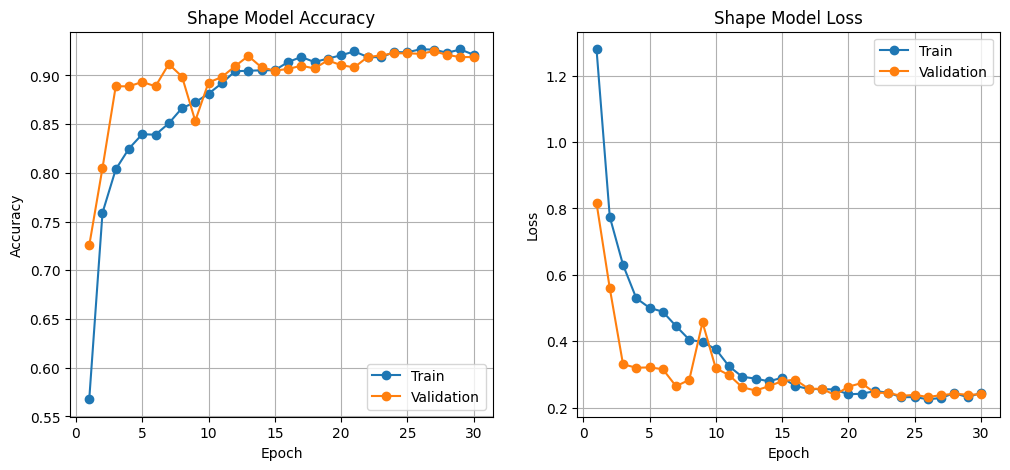

In [ ]:


epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, history.history['accuracy'], marker='o')
plt.plot(epochs_range, history.history['val_accuracy'], marker='o')
plt.title("Shape Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, history.history['loss'], marker='o')
plt.plot(epochs_range, history.history['val_loss'], marker='o')
plt.title("Shape Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np

# Predict on validation/test set
y_pred = np.argmax(shape_model.predict(X_val), axis=1)
y_true = np.argmax(y_val, axis=1)

# ===== Print Test Accuracy (like your screenshot) =====
test_acc = accuracy_score(y_true, y_pred)
print("TEST ACCURACY:", test_acc)

# ===== Classification report as table =====
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=shape_classes,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
TEST ACCURACY: 0.9222222222222223


,precision,recall,f1-score,support
acantocyte,0.994924,0.980000,0.987406,200.000000
elliptocyte,0.719101,0.960000,0.822270,200.000000
hypochromic,0.974359,0.760000,0.853933,200.000000
normal,0.831897,0.965000,0.893519,200.000000
pencil,1.000000,0.915000,0.955614,200.000000
sperobulat,0.984694,0.965000,0.974747,200.000000
stomatocyte,0.987654,0.800000,0.883978,200.000000
target,0.927536,0.960000,0.943489,200.000000
teardrop,0.995000,0.995000,0.995000,200.000000
accuracy,0.922222,0.922222,0.922222,0.922222


In [ ]:
shape_model.save("/content/drive/MyDrive/thalassemia_shape_based/thalassemia")
print("Shape model saved")

Shape model saved


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 8
EPOCHS = 20

In [ ]:
shape_model = tf.keras.models.load_model("/content/shape_modeln2.1.keras")

In [ ]:
def preprocess_image(path):

    img = cv2.imread(path)

    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)

    l = cv2.equalizeHist(l)

    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    img = img / 255.0

    return img

In [ ]:
def get_shape_percentage(img):

    img_small = cv2.resize(img,(64,64))
    img_small = np.expand_dims(img_small,0)

    probs = shape_model.predict(img_small,verbose=0)[0]

    return probs

In [ ]:
def blue_gradient(img):

    blue = np.mean(img[:,:,2])

    return blue

In [ ]:
def extract_shape_and_blue_features(img):

    shape = get_shape_percentage(img)

    blue = blue_gradient(img)

    features = np.concatenate([shape,[blue]])

    return features

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/thalassemia_shape_based/dataset/disease"

image_paths = []
labels = []

for class_name in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_folder):
        continue

    # assign label
    if class_name.lower() == "healthy":
        label = 0
    elif class_name.lower() == "thalassemia":
        label = 1
    else:
        continue

    for root, dirs, files in os.walk(class_folder):

        for file in files:

            if file.lower().endswith((".jpg",".jpeg",".png",".tif",".tiff")):

                full_path = os.path.join(root, file)

                image_paths.append(full_path)
                labels.append(label)

print("Total Images:", len(image_paths))
print("Healthy Images:", labels.count(0))
print("Thalassemia Images:", labels.count(1))

Total Images: 991
Healthy Images: 800
Thalassemia Images: 191


In [ ]:
images = []
extra_features = []

for path in image_paths:

    img = preprocess_image(path)

    images.append(img)

    feature = extract_shape_and_blue_features(img)

    extra_features.append(feature)


images = np.array(images)
extra_features = np.array(extra_features)
labels = np.array(labels)

print("Images shape:",images.shape)
print("Features shape:",extra_features.shape)

Images shape: (991, 96, 96, 3)
Features shape: (991, 10)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_img, X_test_img, X_train_feat, X_test_feat, y_train, y_test = train_test_split(
    images,
    extra_features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2]
)

datagen.fit(X_train_img)

In [ ]:
image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

x = base_model(image_input)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)

feature_input = layers.Input(shape=(X_train_feat.shape[1],))

f = layers.Dense(64, activation="relu")(feature_input)

combined = layers.concatenate([x, f])

z = layers.Dense(64, activation="relu")(combined)
output = layers.Dense(1, activation="sigmoid")(z)

model = tf.keras.Model(
    inputs=[image_input, feature_input],
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(

    [X_train_img, X_train_feat],
    y_train,

    validation_data=([X_test_img,X_test_feat],y_test),

    epochs=30,
    batch_size=16
)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 533ms/step - accuracy: 0.9019 - loss: 0.2182 - val_accuracy: 0.9950 - val_loss: 0.0196
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9993 - loss: 0.0093 - val_accuracy: 0.9950 - val_loss: 0.0141
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9997 - loss: 0.0034 - val_accuracy: 0.9950 - val_loss: 0.0142
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9981 - loss: 0.0036 - val_accuracy: 0.9950 - val_loss: 0.0259
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 5.0993e-04 - val_accuracy: 0.9950 - val_loss: 0.0278
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 1.9008e-04 - val_accuracy: 0.9950 - val_loss: 0.0223
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 2.1058e-04 - val_accuracy: 0.9950 - val_loss: 0.0261
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 1.0678e-04 - val_ac

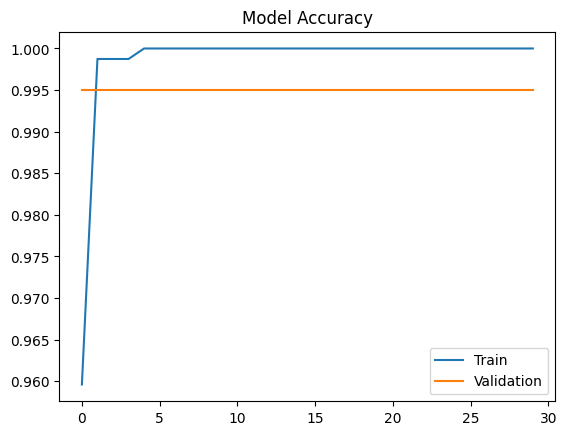

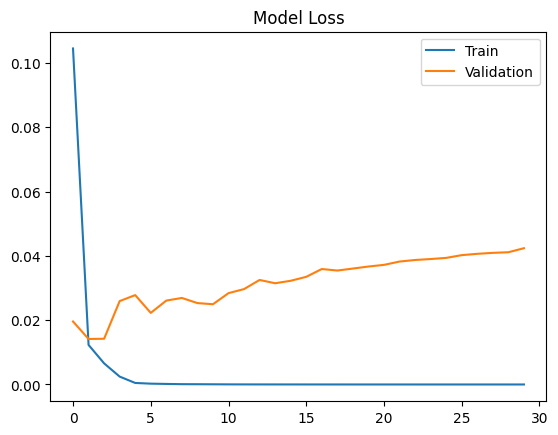

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train","Validation"])
plt.show()

In [ ]:
y_pred = np.argmax(model.predict([X_test_img, X_test_feat]), axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 591ms/step


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

results_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [accuracy, precision, recall, f1]
})

print(results_table)

      Metric     Score
0   Accuracy  0.809045
1  Precision  0.000000
2     Recall  0.000000
3   F1 Score  0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, tf.argmax(predictions[0])]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap,0) / np.max(heatmap)

    return heatmap

In [ ]:
# Save full hybrid model
model.save("thalassemia_hybrid_model_n1.keras")

# Save also in H5 format
model.save("thalassemia_hybrid_model_n1.h5")

print("Model saved successfully!")

In [ ]:
model.save("/content/drive/MyDrive/thalassemia_hybrid_model_n2.1.keras")
model.save("/content/drive/MyDrive/thalassemia_hybrid_model_n2.1.h5")

In [ ]:
import cv2
import numpy as np
import tensorflow as tf

IMG_SIZE = 96

# -----------------------------
# Load Models
# -----------------------------
model = tf.keras.models.load_model("/content/drive/MyDrive/thalassemia_hybrid_model_n2.1.keras")
shape_model = tf.keras.models.load_model("/content/shape_modeln2.1.keras")


# -----------------------------
# Image Preprocessing
# -----------------------------
def preprocess_image(path):

    img = cv2.imread(path)

    if img is None:
        raise ValueError("Image not found")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)

    l = cv2.equalizeHist(l)

    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    img = img / 255.0

    return img


# -----------------------------
# Shape Feature Extraction
# -----------------------------
def get_shape_percentage(img):

    # Resize to 64x64 as the loaded shape_model expects this input size
    img_small = cv2.resize(img,(64,64))
    img_small = np.expand_dims(img_small,0)

    probs = shape_model.predict(img_small,verbose=0)[0]

    return probs


# -----------------------------
# Blue Gradient Feature
# -----------------------------
def blue_gradient(img):

    blue = np.mean(img[:,:,2])

    return blue


# -----------------------------
# Combined Feature Extraction
# -----------------------------
def extract_features(img):

    shape_features = get_shape_percentage(img)

    blue = blue_gradient(img)

    feature_vector = np.append(shape_features, blue)

    return feature_vector


# -----------------------------
# Prediction Function
# -----------------------------
def predict_thalassemia(image_path):

    img = preprocess_image(image_path)

    features = extract_features(img)

    img_input = np.expand_dims(img,0)
    feat_input = np.expand_dims(features,0)

    prediction = model.predict([img_input,feat_input])[0][0]

    print("Prediction Probability:", prediction)

    if prediction >= 0.5:
        print("Prediction: Thalassemia Detected")
    else:
        print("Prediction: Healthy")


# -----------------------------
# Test Prediction
# -----------------------------
predict_thalassemia("/content/drive/MyDrive/thalassemia_shape_based/tha1_test.png")